Importing Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Importing the CSV Files needed for comparison

In [3]:
top3_first_model = pd.read_csv("topK3_evaluation_results_before_recommender_logic_update (First_recommender_logic_results).csv")
top3_current_model = pd.read_csv("topK3_with_artist(25%)_euclidean(75%)_evaluation_results_after_recommender_logic_update (Second_recommender_logic_results).csv")

top5_first_model = pd.read_csv("topK5_evaluation_results_before_recommender_logic_update (First_recommender_logic_results).csv")
top5_current_model = pd.read_csv("topK5_with_artist(25%)_euclidean(75%)_evaluation_results_after_recommender_logic_update (Second_recommender_logic_results).csv")

print(top3_first_model.head())
print(top3_current_model.head())
print(top5_first_model.head())
print(top5_current_model.head())

              Model  Precision    Recall      NDCG
0         Euclidean   0.065359  0.041690  0.063424
1            Cosine   0.052288  0.034967  0.054223
2  Random by Artist   0.398693  0.214683  0.421953
3            Random   0.000000  0.000000  0.000000
              Model  Precision    Recall      NDCG
0         Euclidean   0.189542  0.111905  0.186877
1            Cosine   0.320261  0.178035  0.334320
2  Random by Artist   0.398693  0.217437  0.421953
3            Random   0.000000  0.000000  0.000000
              Model  Precision    Recall      NDCG
0         Euclidean   0.047059  0.047292  0.054790
1            Cosine   0.039216  0.043791  0.048333
2  Random by Artist   0.321569  0.289449  0.371426
3            Random   0.003922  0.003922  0.004196
              Model  Precision    Recall      NDCG
0         Euclidean   0.176471  0.171312  0.188277
1            Cosine   0.270588  0.253268  0.308422
2  Random by Artist   0.337255  0.301774  0.382894
3            Random   0.015686 

## 1. top-k Selection

**Top 3** is used as the **Main Evaluation Metric** 
This is because the playlist dataset only contains playlists with 15 to 40 tracks, which results in approximately **3 to 8 ground truth tracks(20%) for each playlist**. Therefore, **top 3 was selected as the main evaluation metric**. 

If **larger top-k values** were used, we will have **lower Precision and NDCG scores but higher Recall scores**. In many research papers, top-5 and top-10 are commonly used as evaluation metrics, however, considering the size of the dataset and the number of ground-truth tracks available, using evaluation metrics that better match the dataset characteristics can provide more meaningful results. Therefore, **top-3 was selected as the main evaluation metric**, while **top-5 is included as a supporting evaluation metric** as it still falls within the range of the available ground-truth tracks.

## 2. Comparison of first and Current models' [Precision@3, Recall@3, NDCG@3]

In [4]:
comparison_top3 = top3_first_model.merge(
    top3_current_model,
    on="Model",
    suffixes=("_First", "_Current")
)

comparison_top3

,Model,Precision_First,Recall_First,NDCG_First,Precision_Current,Recall_Current,NDCG_Current
0,Euclidean,0.065359,0.041690,0.063424,0.189542,0.111905,0.186877
1,Cosine,0.052288,0.034967,0.054223,0.320261,0.178035,0.334320
2,Random by Artist,0.398693,0.214683,0.421953,0.398693,0.217437,0.421953
3,Random,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


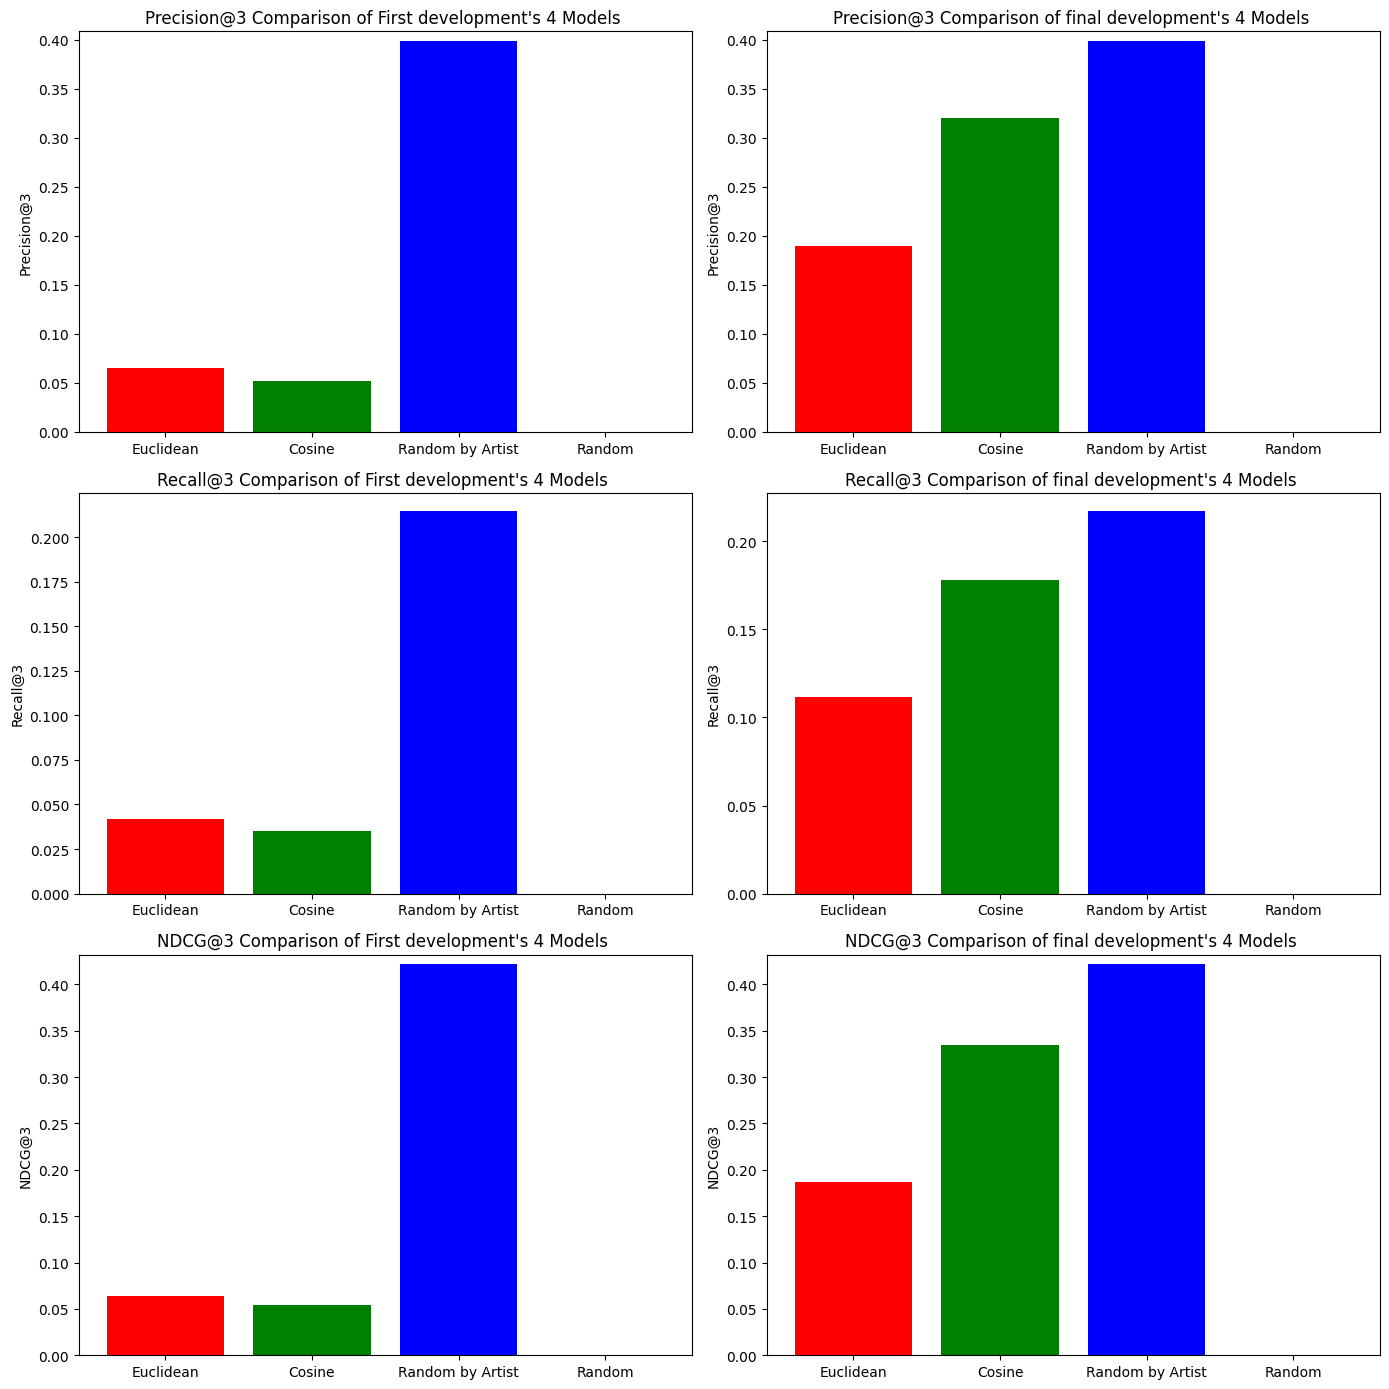

In [31]:
models = ["Euclidean", "Cosine", "Random by Artist", "Random"]

# top 3 values | First model
precision_values_first = comparison_top3["Precision_First"]
recall_values_first = comparison_top3["Recall_First"]
ndcg_values_first = comparison_top3["NDCG_First"]

# top3  values | Current Model
precision_values_current = comparison_top3["Precision_Current"]
recall_values_current = comparison_top3["Recall_Current"]
ndcg_values_current = comparison_top3["NDCG_Current"]

# bar color
color=["red","green","blue","orange"]   
# 3x2 (3 metrics x 2 development models)
fig, axes = plt.subplots(3, 2, figsize=(14,14))

################################First Model#################################
######################### precision @ 3 | First model ########################
bars = axes[0,0].bar(models, precision_values_first, color=color)

axes[0,0].set_title("Precision@3 Comparison of First development's 4 Models ")
axes[0,0].set_ylabel("Precision@3")
axes[0,0].set_ylim(0, max(precision_values_first)+ 0.01) 


######################### recall @ 3 | First model ########################
bars = axes[1,0].bar(models, recall_values_first, color=color)

axes[1,0].set_title("Recall@3 Comparison of First development's 4 Models ")
axes[1,0].set_ylabel("Recall@3")
axes[1,0].set_ylim(0, max(recall_values_first)+ 0.01) 

######################### recall @ 3 | First model ########################
bars = axes[2,0].bar(models, ndcg_values_first, color=color)

axes[2,0].set_title("NDCG@3 Comparison of First development's 4 Models ")
axes[2,0].set_ylabel("NDCG@3")
axes[2,0].set_ylim(0, max(ndcg_values_first)+ 0.01) 


################################Current Model#################################
######################### precision @ 3 | final model ########################
bars = axes[0,1].bar(models, precision_values_current, color=color)

axes[0,1].set_title("Precision@3 Comparison of final development's 4 Models ")
axes[0,1].set_ylabel("Precision@3")
axes[0,1].set_ylim(0, max(precision_values_current)+ 0.01) 


######################### recall @ 3 | First model ########################
bars = axes[1,1].bar(models, recall_values_current, color=color)

axes[1,1].set_title("Recall@3 Comparison of final development's 4 Models ")
axes[1,1].set_ylabel("Recall@3")
axes[1,1].set_ylim(0, max(recall_values_current)+ 0.01) 

######################### recall @ 3 | First model ########################
bars = axes[2,1].bar(models, ndcg_values_current, color=color)

axes[2,1].set_title("NDCG@3 Comparison of final development's 4 Models ")
axes[2,1].set_ylabel("NDCG@3")
axes[2,1].set_ylim(0, max(ndcg_values_current)+ 0.01) 

plt.tight_layout()
plt.show()


The graphs show the comparison of Euclidean, Consine, Random-by-artist and Random models across different evaluation metrics.Precision is shown in the first row, Recall in the second row, and NDCG in the third row. The left column shows the results after the first development, while the right column shows the result of the current model after the improvements to the recommender logic.

The results show that after the first development, the Euclidean and Cosine models had similar performance across all evaluation metrics. Both models performed better than the random model, producing around 0.03 to 0.065 across all metrics. However, the random-by-artist model performed about 10 times better than these two models, indicating that the 'artist' feature has a strong influence on user listening behaviour. This observation led to the improvement of the recommender logic by incorporating artist similarity.

After the improvement, both the Euclidean and Cosine models show significant performance improvements. The Cosine model improves the most, producing results that are almost similar to Random-by-artist model. The Euclidean model also shows clear improvements, although its results remain lower than the Cosine model. The Random model remains close to 0.0, indicating that the recommendation logic performs significantly better than random selection. Since one of the main aims of this project was to develop a recommender system that outperforms a random baseline, these results demonstrate that the developed models successfully achieve the project objective.

These results suggest that the recommender logic using Euclidean and Cosine similarity is functioning effectively, although the dataset used for evaluation may have some bias toward artist similarity, or users may naturally tend to listen to songs from the same artists.


In [32]:
current_top3_results = comparison_top3[['Model','Precision_Current', 'Recall_Current', 'NDCG_Current']].copy()
current_top3_results

,Model,Precision_Current,Recall_Current,NDCG_Current
0,Euclidean,0.189542,0.111905,0.186877
1,Cosine,0.320261,0.178035,0.334320
2,Random by Artist,0.398693,0.217437,0.421953
3,Random,0.000000,0.000000,0.000000


In this project, Precision and NDCG are considered more important than Recall, as they better reflect the quality and ranking of the recommended songs. Results above 0.3 are considered good performance within the scope of this project. Two models achieve this level: the Cosine model and the Random-by-Artist model, while both models also achieve around 0.2 in Recall.

However, the Random-by-Artist model was designed as a baseline model, and therefore selecting it as the final recommender logic was never the intended option. Although the Random-by-Artist model produces slightly higher evaluation scores, it relies entirely on the artist feature, which may lead to overly strong artist bias in the recommendations.

Therefore, the Cosine model was selected as the main recommender logic, as it provides competitive results while relying on audio feature similarity combined with artist similarity, allowing the system to recommend songs based on song characteristics rather than artist identity alone. 


## 3. Comparison of first and Current models' [Precision@5, Recall@5, NDCG@5]

In [5]:
comparison_top5 = top5_first_model.merge(
    top5_current_model,
    on="Model",
    suffixes=("_First", "_Current")
)

comparison_top5

,Model,Precision_First,Recall_First,NDCG_First,Precision_Current,Recall_Current,NDCG_Current
0,Euclidean,0.047059,0.047292,0.054790,0.176471,0.171312,0.188277
1,Cosine,0.039216,0.043791,0.048333,0.270588,0.253268,0.308422
2,Random by Artist,0.321569,0.289449,0.371426,0.337255,0.301774,0.382894
3,Random,0.003922,0.003922,0.004196,0.015686,0.011975,0.019238


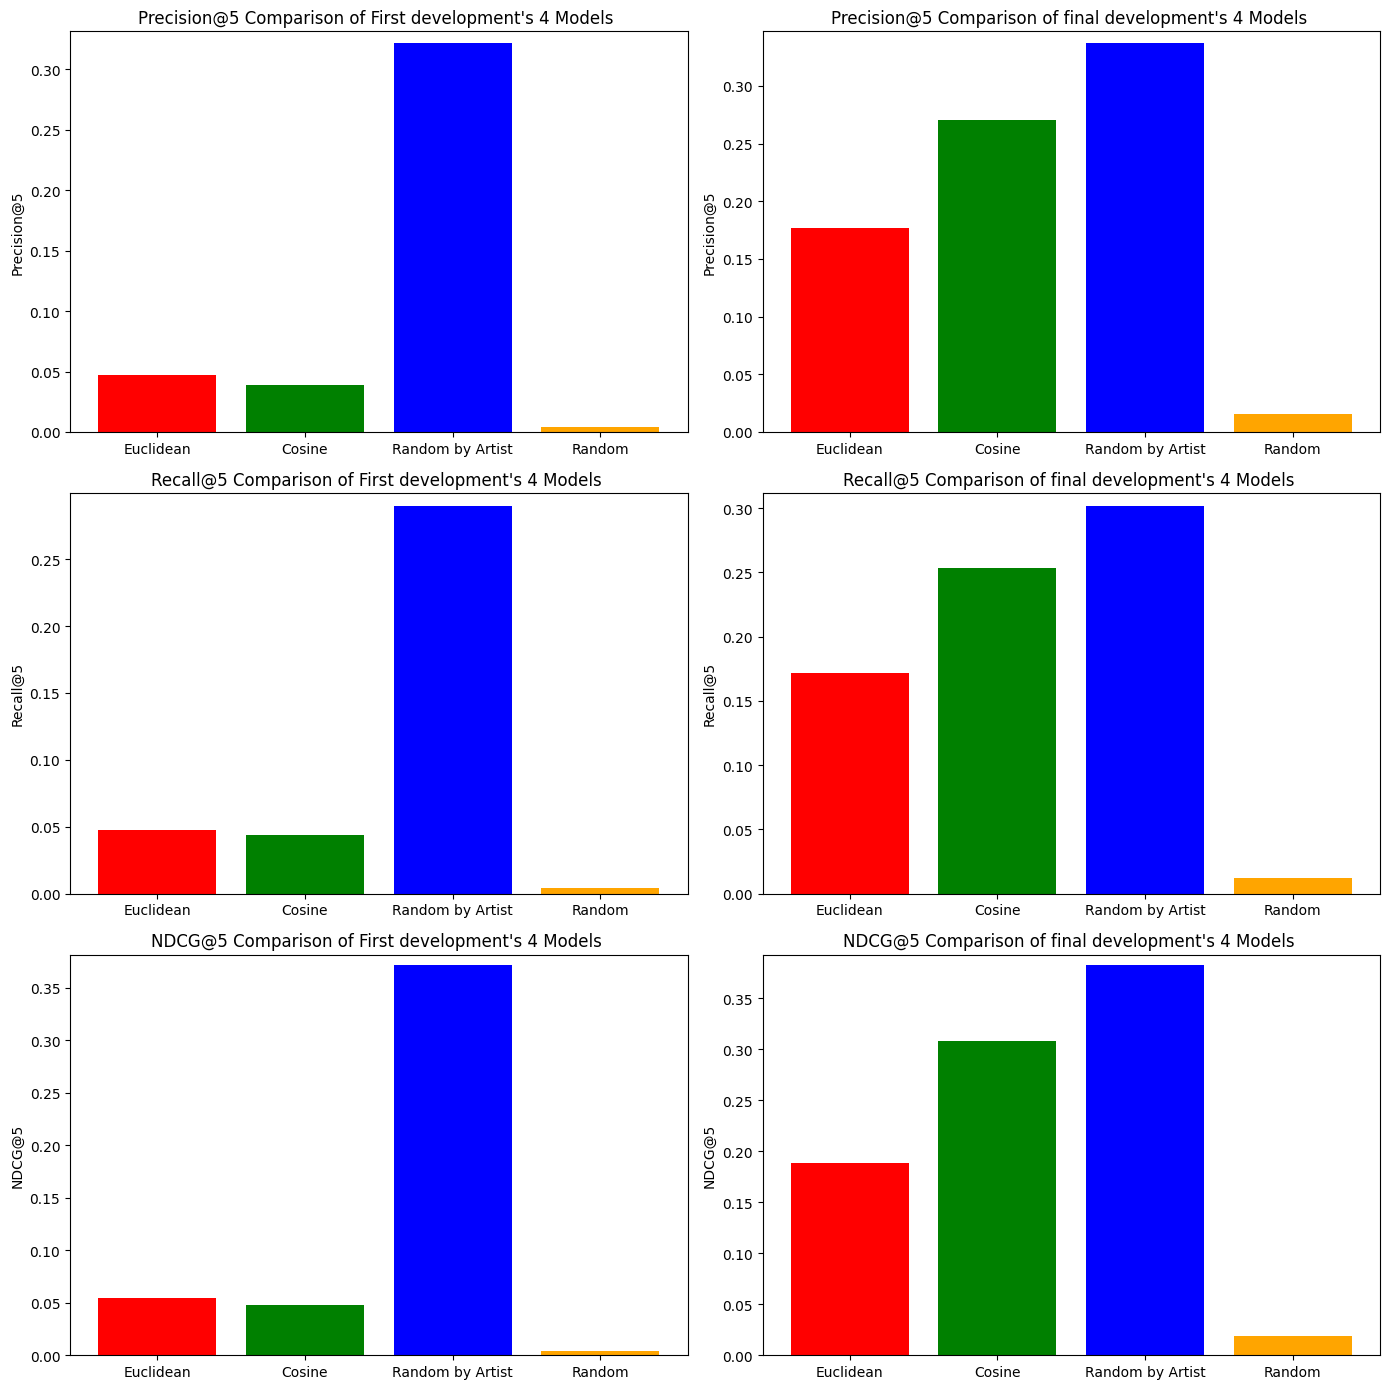

In [70]:
models = ["Euclidean", "Cosine", "Random by Artist", "Random"]

# top 5 values | First model
precision5_values_first = comparison_top5["Precision_First"]
recall5_values_first = comparison_top5["Recall_First"]
ndcg5_values_first = comparison_top5["NDCG_First"]

# top 5  values | Current Model
precision5_values_current = comparison_top5["Precision_Current"]
recall5_values_current = comparison_top5["Recall_Current"]
ndcg5_values_current = comparison_top5["NDCG_Current"]

# bar color
color=["red","green","blue","orange"]   
# 3x2 (3 metrics x 2 development models)
fig, axes = plt.subplots(3, 2, figsize=(14,14))

################################First Model#################################
######################### precision @ 5 | First model ########################
bars = axes[0,0].bar(models, precision5_values_first, color=color)

axes[0,0].set_title("Precision@5 Comparison of First development's 4 Models ")
axes[0,0].set_ylabel("Precision@5")
axes[0,0].set_ylim(0, max(precision5_values_first)+ 0.01) 


######################### recall @ 5 | First model ########################
bars = axes[1,0].bar(models, recall5_values_first, color=color)

axes[1,0].set_title("Recall@5 Comparison of First development's 4 Models ")
axes[1,0].set_ylabel("Recall@5")
axes[1,0].set_ylim(0, max(recall5_values_first)+ 0.01) 

######################### recall @ 5 | First model ########################
bars = axes[2,0].bar(models, ndcg5_values_first, color=color)

axes[2,0].set_title("NDCG@5 Comparison of First development's 4 Models ")
axes[2,0].set_ylabel("NDCG@5")
axes[2,0].set_ylim(0, max(ndcg5_values_first)+ 0.01) 


################################Current Model#################################
######################### precision @ 5 | final model ########################
bars = axes[0,1].bar(models, precision5_values_current, color=color)

axes[0,1].set_title("Precision@5 Comparison of final development's 4 Models ")
axes[0,1].set_ylabel("Precision@5")
axes[0,1].set_ylim(0, max(precision5_values_current)+ 0.01) 


######################### recall @ 5 | First model ########################
bars = axes[1,1].bar(models, recall5_values_current, color=color)

axes[1,1].set_title("Recall@5 Comparison of final development's 4 Models ")
axes[1,1].set_ylabel("Recall@5")
axes[1,1].set_ylim(0, max(recall5_values_current)+ 0.01) 

######################### recall @ 5 | First model ########################
bars = axes[2,1].bar(models, ndcg5_values_current, color=color)

axes[2,1].set_title("NDCG@5 Comparison of final development's 4 Models ")
axes[2,1].set_ylabel("NDCG@5")
axes[2,1].set_ylim(0, max(ndcg5_values_current)+ 0.01) 

plt.tight_layout()
plt.show()

In [71]:
current_top5_results = comparison_top5[['Model','Precision_Current', 'Recall_Current', 'NDCG_Current']].copy()
current_top5_results

,Model,Precision_Current,Recall_Current,NDCG_Current
0,Euclidean,0.176471,0.171312,0.188277
1,Cosine,0.270588,0.253268,0.308422
2,Random by Artist,0.337255,0.301774,0.382894
3,Random,0.015686,0.011975,0.019238


The top5 results follow a similar pattern to the top3 results for all models. After the first development, the Euclidean and Cosine models had similar performance. However, after the improvement of recommender logic, the Cosine model produces better results than the Euclidean model, even though both models show clear improvements in their evaluation scores. 

Before the improvement, the Randon-by-artist model performed significantly better than the other models, while the Radnom model remained close to 0.0. After the improvement, the Cosine model improves significantly, with results that are relatively close to the Random-by-Artist model. 

Overall, the top-3 and top-5 evaluations show similar trends across all models. The top-5 results are slightly lower than the top-3 results, which is expected because recommending more items increases the likelihood of including less relevant songs. Additionally, the limited number of ground-truth tracks (3 to 8 tracks) in the dataset may also affect the top-5 evaluation results.

## 4. Improvement of models after first iterative development 

In [33]:
# top 3 improvement after mode update
comparison_top3["Precision_Improvement"] = (comparison_top3["Precision_Current"] - comparison_top3["Precision_First"])

comparison_top3["Recall_Improvement"] = (comparison_top3["Recall_Current"] - comparison_top3["Recall_First"])

comparison_top3["NDCG_Improvement"] = (comparison_top3["NDCG_Current"] - comparison_top3["NDCG_First"])

# Select relevant columns
top3_improvements = comparison_top3[["Model", "Precision_Improvement", "Recall_Improvement", "NDCG_Improvement"]].copy()
top3_improvements

,Model,Precision_Improvement,Recall_Improvement,NDCG_Improvement
0,Euclidean,1.241830e-01,0.070215,0.123453
1,Cosine,2.679739e-01,0.143067,0.280097
2,Random by Artist,-1.665335e-16,0.002754,0.000000
3,Random,0.000000e+00,0.000000,0.000000


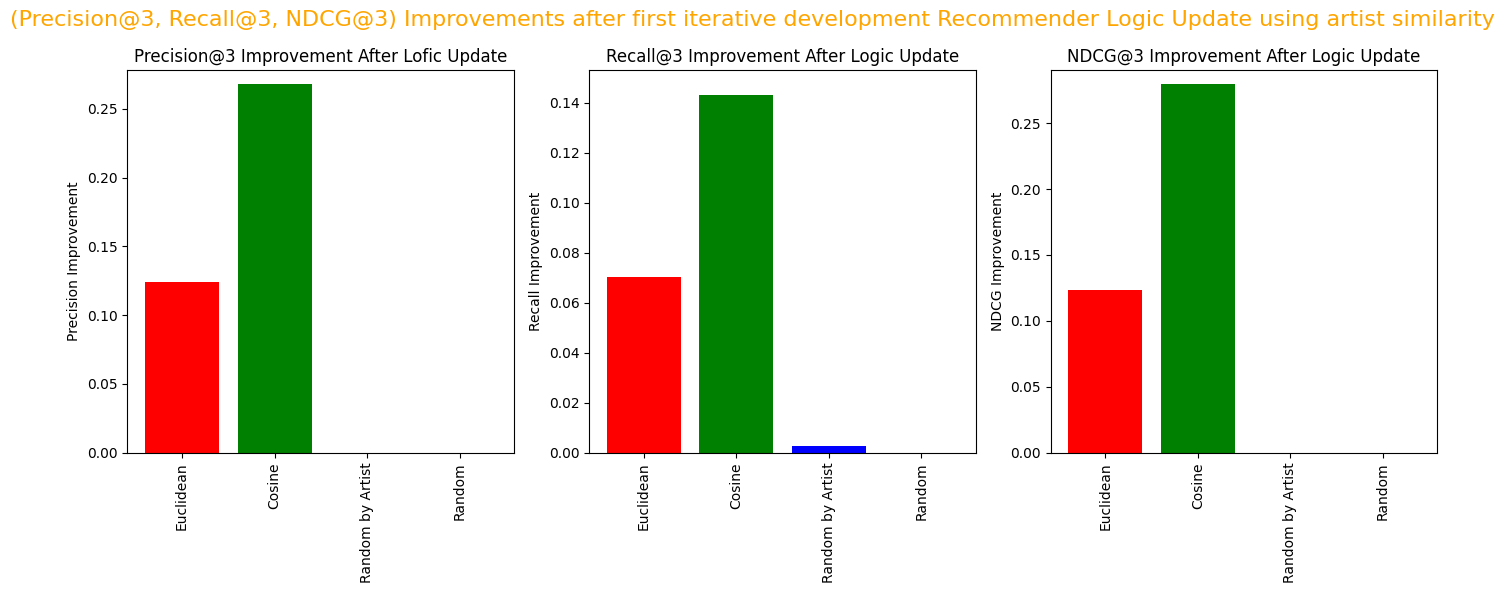

In [51]:
prec_imp = top3_improvements["Precision_Improvement"]
rec_imp = top3_improvements["Recall_Improvement"]
ndcg_imp = top3_improvements["NDCG_Improvement"]

# 1 row , 3 col
fig, axes = plt.subplots(1, 3, figsize=(14,6))

# ############## precision improvment | top 3 ################# 
bars = axes[0].bar(models, prec_imp, color=color)
axes[0].set_title("Precision@3 Improvement After Lofic Update")
axes[0].set_ylabel("Precision Improvement")
axes[0].set_ylim(0, prec_imp.max()+0.01)
axes[0].tick_params(axis='x', rotation=90)

# ############## recall improvment | top 3 ################# 
bars = axes[1].bar(models, rec_imp, color=color)
axes[1].set_title("Recall@3 Improvement After Logic Update")
axes[1].set_ylabel("Recall Improvement")
axes[1].set_ylim(0, rec_imp.max()+0.01)
axes[1].tick_params(axis='x', rotation=90)

# ############## NDCG improvment | top 3 ################# 
bars = axes[2].bar(models, ndcg_imp, color=color)
axes[2].set_title("NDCG@3 Improvement After Logic Update")
axes[2].set_ylabel("NDCG Improvement")
axes[2].set_ylim(0, ndcg_imp.max()+0.01)
axes[2].tick_params(axis='x', rotation=90)

fig.suptitle('(Precision@3, Recall@3, NDCG@3) Improvements after first iterative development Recommender Logic Update using artist similarity', fontsize=16, color='orange')
plt.tight_layout()
plt.show()

The above graphs show the improvements in Precision, Recall, and NDCG scores after the recommender logic was updated by considering the artist similarity.

The Cosine similarity model shows the most significant improvements: around 0.14 in Recall and around 0.25 in Precision and NDCG. The Euclidean model also improves, with approximately 0.07 in Recall and around 0.12 in Precision and NDCG. Both models show good improvements, but the Cosine model improves roughly twice as much as the Euclidean model.

These results indicate that my finding about the importance of artist similarity is correct and the iterative development of the recommender logic effectively enhanced the performance, with the Cosine model now performing the best among the tested models.

## 5. Cosine vs Random by Artist

In [54]:
cosine_vs_artist = comparison_top3[comparison_top3["Model"].isin(["Cosine", "Random by Artist"])] [["Model","Precision_Current","Recall_Current","NDCG_Current"]].copy()

cosine_vs_artist

,Model,Precision_Current,Recall_Current,NDCG_Current
1,Cosine,0.320261,0.178035,0.334320
2,Random by Artist,0.398693,0.217437,0.421953


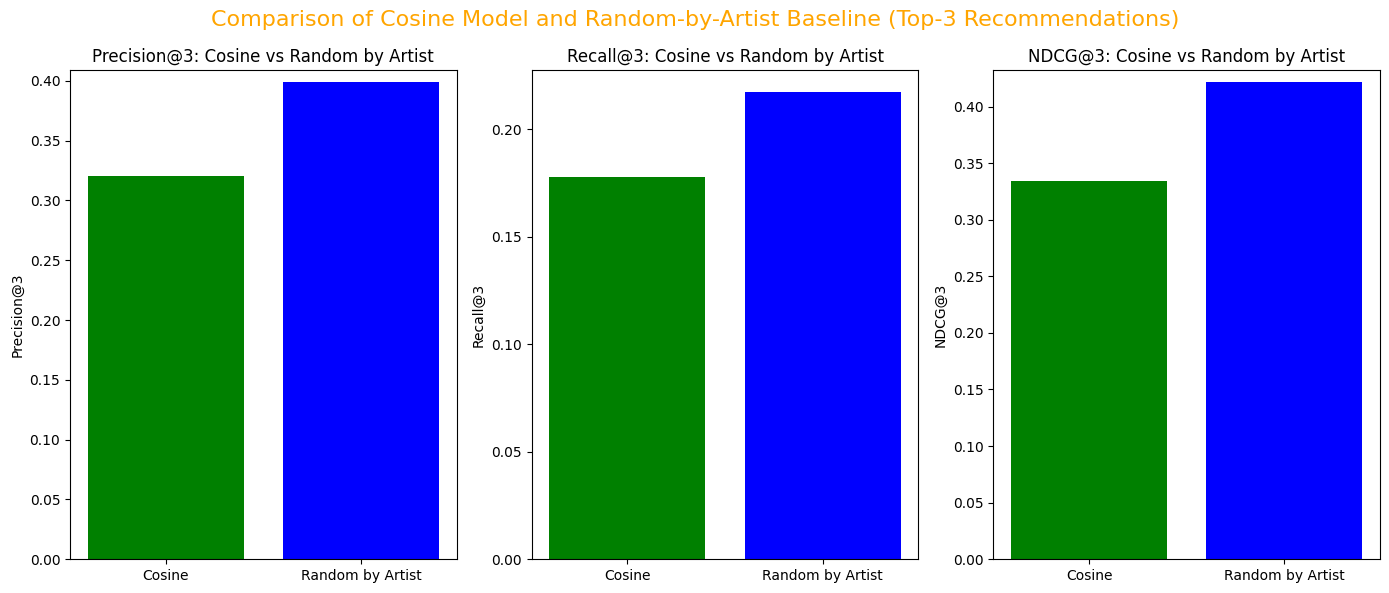

In [58]:
models_compare = ["Cosine", "Random by Artist"]
color_compare = ["green","blue"]

prec_compare = cosine_vs_artist["Precision_Current"]
rec_compare = cosine_vs_artist["Recall_Current"]
ndcg_compare = cosine_vs_artist["NDCG_Current"]


# 1 row , 3 columns
fig, axes = plt.subplots(1, 3, figsize=(14,6))

############## Precision @3 ################
bars = axes[0].bar(models_compare, prec_compare, color=color_compare)

axes[0].set_title("Precision@3: Cosine vs Random by Artist")
axes[0].set_ylabel("Precision@3")
axes[0].set_ylim(0, max(prec_compare)+0.01)

############## Recall @3 ################
bars = axes[1].bar(models_compare, rec_compare, color=color_compare)

axes[1].set_title("Recall@3: Cosine vs Random by Artist")
axes[1].set_ylabel("Recall@3")
axes[1].set_ylim(0, max(rec_compare)+0.01)

############## NDCG @3 ################
bars = axes[2].bar(models_compare, ndcg_compare, color=color_compare)

axes[2].set_title("NDCG@3: Cosine vs Random by Artist")
axes[2].set_ylabel("NDCG@3")
axes[2].set_ylim(0, max(ndcg_compare)+0.01)

fig.suptitle("Comparison of Cosine Model and Random-by-Artist Baseline (Top-3 Recommendations)", fontsize=16, color='orange')

plt.tight_layout()
plt.show()

The above graph shows the Precsion@3, Recall@3, NDCG@3 results comparing the Cosine Model and the Random-by-artist model. The results show that Random-by-artist model performs slightly better than the Cosine model. However, their results are similar, and the difference between the two models does not exceed 0.1 for any of the evaluation metrics. 

The **Cosine model** uses **both audio features and artist similarity**, while the **Random-by-Artist model** relies only on the **artist feature**. Therefore, using Cosine model is more appropriate, as it does not rely solely on artist similarity even though its results are slightly lower than the Randon-by-artist model. 

Using the **Cosine model** also allows the system to recommend songs based on **audio similarity**, rather than recommending songs mainly from the same artist. This approach provides **more meaningful recommendations to any users by focusing on the similarity of the songs themselves, rather than only the artist**.

## 6. Other Findings I want to mention

### Comparison of first and Current Euclidean and Cosine Models

In [61]:
# Filter only Euclidean and Cosine
E_vs_C_first_vs_current= comparison_top3[comparison_top3["Model"].isin(["Euclidean", "Cosine"])][["Model","Precision_First","Recall_First","NDCG_First","Precision_Current","Recall_Current","NDCG_Current"]]

E_vs_C_first_vs_current

,Model,Precision_First,Recall_First,NDCG_First,Precision_Current,Recall_Current,NDCG_Current
0,Euclidean,0.065359,0.041690,0.063424,0.189542,0.111905,0.186877
1,Cosine,0.052288,0.034967,0.054223,0.320261,0.178035,0.334320


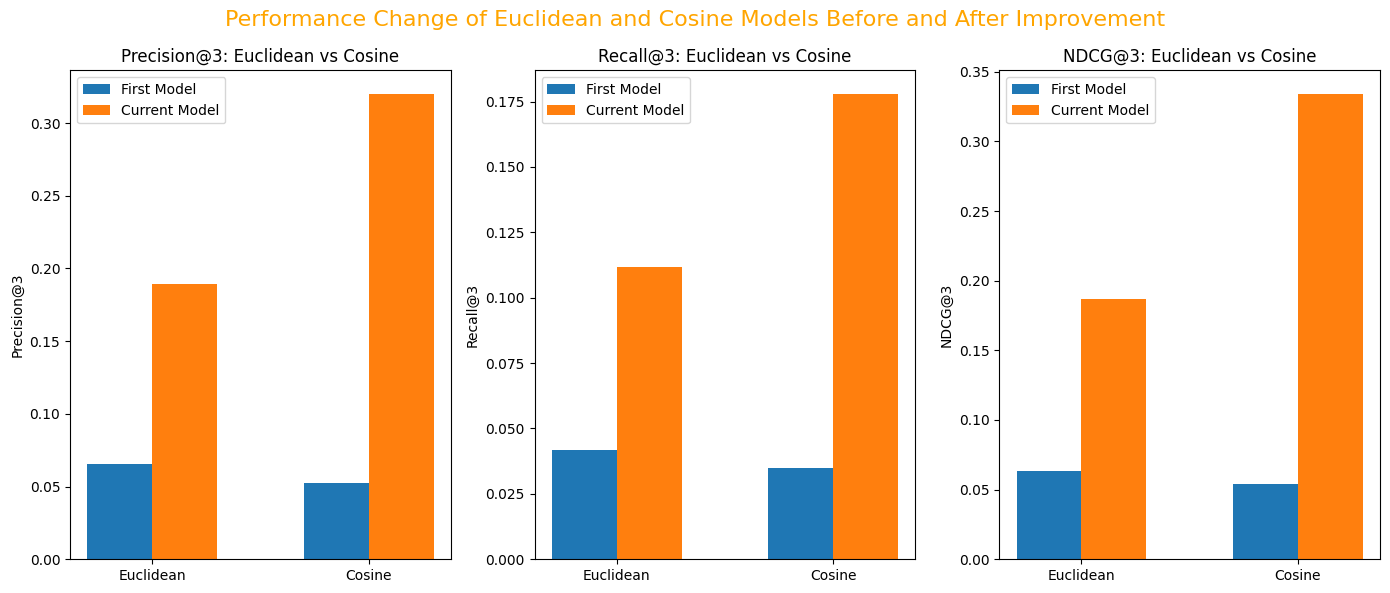

In [69]:

models_ec = ["Euclidean", "Cosine"]
color_ec = ['red','green']

prec_first = E_vs_C_first_vs_current["Precision_First"]
rec_first = E_vs_C_first_vs_current["Recall_First"]
ndcg_first = E_vs_C_first_vs_current["NDCG_First"]

prec_current = E_vs_C_first_vs_current["Precision_Current"]
rec_current = E_vs_C_first_vs_current["Recall_Current"]
ndcg_current = E_vs_C_first_vs_current["NDCG_Current"]

fig, axes = plt.subplots(1,3, figsize=(14,6))

width = 0.3
x = np.arange(len(models_ec))

############ Precision ############
axes[0].bar(x - width/2, prec_first, width, label="First Model")
axes[0].bar(x + width/2, prec_current, width, label="Current Model")

axes[0].set_xticks(x)
axes[0].set_xticklabels(models_ec)
axes[0].set_title("Precision@3: Euclidean vs Cosine")
axes[0].set_ylabel("Precision@3")
axes[0].legend()

############ Recall ############
axes[1].bar(x - width/2, rec_first, width, label="First Model")
axes[1].bar(x + width/2, rec_current, width, label="Current Model")

axes[1].set_xticks(x)
axes[1].set_xticklabels(models_ec)
axes[1].set_title("Recall@3: Euclidean vs Cosine")
axes[1].set_ylabel("Recall@3")
axes[1].legend()

############ NDCG ############
axes[2].bar(x - width/2, ndcg_first, width, label="First Model")
axes[2].bar(x + width/2, ndcg_current, width, label="Current Model")

axes[2].set_xticks(x)
axes[2].set_xticklabels(models_ec)
axes[2].set_title("NDCG@3: Euclidean vs Cosine")
axes[2].set_ylabel("NDCG@3")
axes[2].legend()

fig.suptitle(
    "Performance Change of Euclidean and Cosine Models Before and After Improvement",
    fontsize=16,
    color="orange"
)

plt.tight_layout()
plt.show()

The above graph shows the difference in performance between the Euclidean and Cosine models before and after the recommender logic improvement during the iterative development.

After the first development, before the improvement, the Euclidean model was performing slightly better than the Cosine model. However, after adding artist similarity to recommender logic, the Cosine model performs significantly better than the Euclidean model. 

This difference may be related to the characteristics of the two similarity measures. The Euclidean distance relies mainly on the magnitude difference between feature values, while the Cosine similarity measures the angles between two feature vectors.